# MLPClassifier (Rede Neural)

## Foco: Treinar um classificador de rede neural (Multi-layer Perceptron).

**Justificativa Estratégica:** Após a análise dos modelos de árvore e lineares, identificamos uma lacuna na detecção de ataques web raros e complexos. Os modelos de árvore (Random Forest, XGBoost) são eficazes no geral, mas falham em generalizar para essas classes. Os modelos lineares (Regressão Logística, SGD) são incapazes de capturar a complexidade não-linear do problema.

**Hipótese:** Uma rede neural, através do `MLPClassifier`, pode ser capaz de aprender os padrões não-lineares sutis que caracterizam os ataques web raros, de uma forma que os modelos baseados em árvores não conseguem. Se bem-sucedido, este modelo adicionará uma diversidade de "pensamento" crucial ao nosso ensemble final.

**Metodologia:** O `MLPClassifier` é altamente sensível à escala das features, portanto, o uso de dados padronizados (`StandardScaler`) é **obrigatório**.

### Importação das bibliotecas:

In [1]:
import pandas as pd
import numpy as np
import glob
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_curve, auc
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### 2. Carregamento dos Artefatos e dos Dados

 1. Carregamos os artefatos (LabelEncoder, lista de features) para garantir consistência.
 2. Carregamos e limpamos os dados brutos.
 3. Aplicamos a **Padronização das Features** (`StandardScaler`), que é um
    pré-requisito não-negociável para o bom funcionamento de redes neurais.

In [4]:
# --- 1. Carrega os artefatos salvos ---
import os
import joblib
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import glob

# Define o caminho absoluto para a pasta 'models'
try:
    project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
except:
    project_root = os.getcwd()

model_dir = os.path.join(project_root, 'models')

# Carrega o codificador de rótulos e a lista de features
try:
    label_encoder = joblib.load(os.path.join(model_dir, 'label_encoder.joblib'))
    features_realistas = joblib.load(os.path.join(model_dir, 'features_realistas.joblib'))
    print("Artefatos (LabelEncoder e lista de features) carregados com sucesso.")
except FileNotFoundError:
    raise RuntimeError("ERRO: Artefatos do Notebook 01 não encontrados.")

# --- 2. Carrega e limpa os dados ---
caminho_dados = os.path.join(project_root, 'MachineLearningCSV', 'MachineLearningCVE')
todos_os_arquivos = glob.glob(os.path.join(caminho_dados, "*.csv"))
lista_de_dfs = []
for arquivo in todos_os_arquivos:
    df = pd.read_csv(arquivo, low_memory=False)
    lista_de_dfs.append(df)
dados = pd.concat(lista_de_dfs, axis=0, ignore_index=True)
dados.columns = dados.columns.str.strip()
for col in dados.columns:
    if dados[col].dtype == 'object' and col != 'Label':
        dados[col] = pd.to_numeric(dados[col], errors='coerce')
dados.replace([np.inf, -np.inf], np.nan, inplace=True)
dados.dropna(inplace=True)
X_bruto = dados.drop('Label', axis=1)
y_bruto = dados['Label']
y_codificado = label_encoder.transform(y_bruto)
X_realista = X_bruto[features_realistas]
print("\nDataset carregado e processado.")

Artefatos (LabelEncoder e lista de features) carregados com sucesso.

Dataset carregado e processado.


### 3. Divisão dos Dados em Treino e Teste

 A etapa de divisão é a mesma, utilizando os dados padronizados (`X_padronizado`) para garantir que a rede neural receba os dados na escala correta, o que é crucial para uma convergência estável e eficiente do treinamento.

In [5]:
X_treino_bruto, X_teste_bruto, y_treino, y_teste = train_test_split(
    X_realista, y_codificado, test_size=0.3, random_state=42, stratify=y_codificado
)
print("\nDados divididos em treino e teste.")

# --- 4. Padronização das Features (DA FORMA CORRETA) ---
print("Iniciando a padronização das features (sem data leakage)...")
scaler = StandardScaler()

# Aprende a padronização APENAS com os dados de treino
scaler.fit(X_treino_bruto)

# Aplica a padronização nos dois conjuntos
X_treino = scaler.transform(X_treino_bruto)
X_teste = scaler.transform(X_teste_bruto)

print("Padronização concluída.")
print(f"Shape do conjunto de treino (X_treino): {X_treino.shape}")
print(f"Shape do conjunto de teste (X_teste):   {X_teste.shape}")



Dados divididos em treino e teste.
Iniciando a padronização das features (sem data leakage)...
Padronização concluída.
Shape do conjunto de treino (X_treino): (1979513, 14)
Shape do conjunto de teste (X_teste):   (848363, 14)


## 4. Otimização com GridSearchCV e Validação Cruzada

Para o `MLPClassifier`, o ajuste de hiperparâmetros é ainda mais crítico, pois define a própria arquitetura da rede neural. Utilizamos o `GridSearchCV` para testar diferentes arquiteturas (número de camadas e neurônios) e forças de regularização (`alpha`). A busca é realizada no conjunto de treino completo e padronizado para encontrar a configuração que maximiza a performance de generalização do modelo.

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier

print("--- Iniciando GridSearchCV para o MLPClassifier ---")
print("AVISO: Este processo será demorado.")

# 1. Define a grade de parâmetros para o MLP
param_grid_mlp = {
    'hidden_layer_sizes': [(50, 25), (100, 50)],  # Arquitetura: uma mais simples, outra a original
    'alpha': [0.0001, 0.001],                     # Força da regularização L2
    'learning_rate_init': [0.001]                # Mantemos a taxa de aprendizado fixa por enquanto
}

# 2. Instancia o GridSearchCV
# Usamos n_jobs=2 para evitar problemas de memória
grid_search_mlp = GridSearchCV(
    estimator=MLPClassifier(random_state=42, early_stopping=True, validation_fraction=0.1),
    param_grid=param_grid_mlp,
    cv=3,
    n_jobs=2,
    verbose=2,
    scoring='f1_weighted'
)

# 3. Executa a busca no CONJUNTO DE TREINO COMPLETO E PADRONIZADO
grid_search_mlp.fit(X_treino, y_treino)

# 4. Mostra os melhores parâmetros encontrados
print("\n--- GridSearchCV Concluído ---")
print("Melhores parâmetros encontrados para MLPClassifier:")
print(grid_search_mlp.best_params_)

# Armazena os melhores parâmetros
best_mlp_params = grid_search_mlp.best_params_

--- Iniciando GridSearchCV para o MLPClassifier ---
AVISO: Este processo será demorado.
Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END alpha=0.0001, hidden_layer_sizes=(50, 25), learning_rate_init=0.001; total time= 1.5min
[CV] END alpha=0.0001, hidden_layer_sizes=(50, 25), learning_rate_init=0.001; total time= 2.1min
[CV] END alpha=0.0001, hidden_layer_sizes=(50, 25), learning_rate_init=0.001; total time= 4.6min
[CV] END alpha=0.0001, hidden_layer_sizes=(100, 50), learning_rate_init=0.001; total time= 4.4min
[CV] END alpha=0.0001, hidden_layer_sizes=(100, 50), learning_rate_init=0.001; total time=12.1min
[CV] END alpha=0.0001, hidden_layer_sizes=(100, 50), learning_rate_init=0.001; total time=12.2min
[CV] END alpha=0.001, hidden_layer_sizes=(50, 25), learning_rate_init=0.001; total time= 2.4min
[CV] END alpha=0.001, hidden_layer_sizes=(50, 25), learning_rate_init=0.001; total time= 3.2min
[CV] END alpha=0.001, hidden_layer_sizes=(50, 25), learning_rate_init=0.001

### 4. Treinamento do Modelo MLPClassifier

 Parâmetros importantes:
 - `hidden_layer_sizes=(100, 50)`: Esta é a **arquitetura** da nossa rede.
   Significa que teremos duas camadas ocultas: a primeira com 100 neurônios e a segunda com 50.
   É uma arquitetura robusta para começar, capaz de aprender padrões complexos.
 - `activation='relu'`: A função de ativação "Rectified Linear Unit". É a mais comum e eficiente para a maioria dos problemas.
 - `solver='adam'`: Um otimizador avançado que adapta a taxa de aprendizado.
 - `early_stopping=True`: Uma técnica contra overfitting. O modelo reserva uma parte dos dados de treino para validação e para o treinamento se a performance nesses dados de validação parar de melhorar.
 - `verbose=True`: Nos mostrará o progresso do treinamento a cada iteração (época).

In [7]:
print("--- Treinando o Modelo MLPClassifier Final com os Parâmetros Otimizados ---")

# Instancia o modelo com os MELHORES parâmetros encontrados
mlp_model = MLPClassifier(
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=True,  # Ativamos o verbose para ver o progresso do treino final
    **best_mlp_params
)

# Treina o modelo final no conjunto de treino COMPLETO e PADRONIZADO
mlp_model.fit(X_treino, y_treino)

print("\n--- Treinamento do modelo final concluído ---")

--- Treinando o Modelo MLPClassifier Final com os Parâmetros Otimizados ---
Iteration 1, loss = 0.27349869
Validation score: 0.923769
Iteration 2, loss = 0.18584361
Validation score: 0.929427
Iteration 3, loss = 0.16935129
Validation score: 0.928326
Iteration 4, loss = 0.16280449
Validation score: 0.928745
Iteration 5, loss = 0.15889122
Validation score: 0.929341
Iteration 6, loss = 0.15621215
Validation score: 0.931736
Iteration 7, loss = 0.15402820
Validation score: 0.932706
Iteration 8, loss = 0.15171181
Validation score: 0.931398
Iteration 9, loss = 0.15045098
Validation score: 0.932625
Iteration 10, loss = 0.14909211
Validation score: 0.935702
Iteration 11, loss = 0.14735609
Validation score: 0.934085
Iteration 12, loss = 0.14628699
Validation score: 0.934792
Iteration 13, loss = 0.14495661
Validation score: 0.939546
Iteration 14, loss = 0.14350782
Validation score: 0.941228
Iteration 15, loss = 0.14209210
Validation score: 0.936924
Iteration 16, loss = 0.14082711
Validation score

### 5. Avaliação do Modelo

 Agora, vamos submeter nossa rede neural ao mesmo processo de avaliação dos outros modelos.

 As perguntas que queremos responder são:
 1. Como a performance geral (F1-score ponderado) se compara aos nossos outros modelos (RF, XGBoost, CatBoost)?
 2. Mais importante: o `MLPClassifier` conseguiu um `recall` e `precision` melhores para as classes de `Web Attack`?
3. Ele conseguiu ser o "especialista" que estávamos procurando?

--- Relatório de Classificação (MLPClassifier) ---
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.95      0.97    681396
                       Bot       0.87      0.36      0.51       587
                      DDoS       0.80      0.82      0.81     38408
             DoS GoldenEye       0.00      0.00      0.00      3088
                  DoS Hulk       0.81      1.00      0.89     69037
          DoS Slowhttptest       0.98      0.12      0.22      1650
             DoS slowloris       0.82      0.27      0.41      1739
               FTP-Patator       0.87      1.00      0.93      2380
                Heartbleed       0.00      0.00      0.00         3
              Infiltration       0.00      0.00      0.00        11
                  PortScan       0.69      0.99      0.81     47641
               SSH-Patator       0.55      0.51      0.53      1769
  Web Attack � Brute Force       0.00      0.00      0.00       

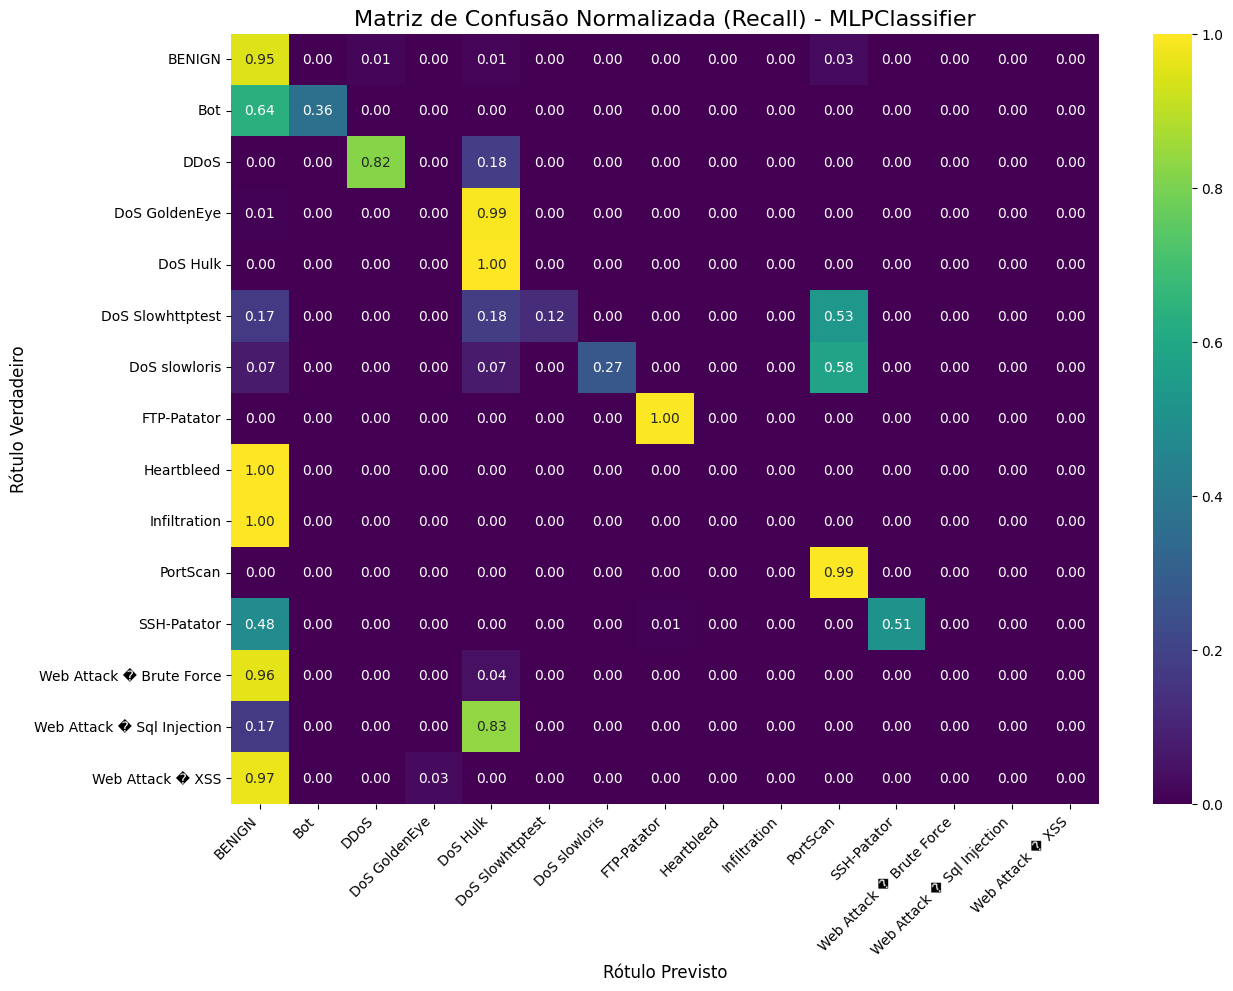

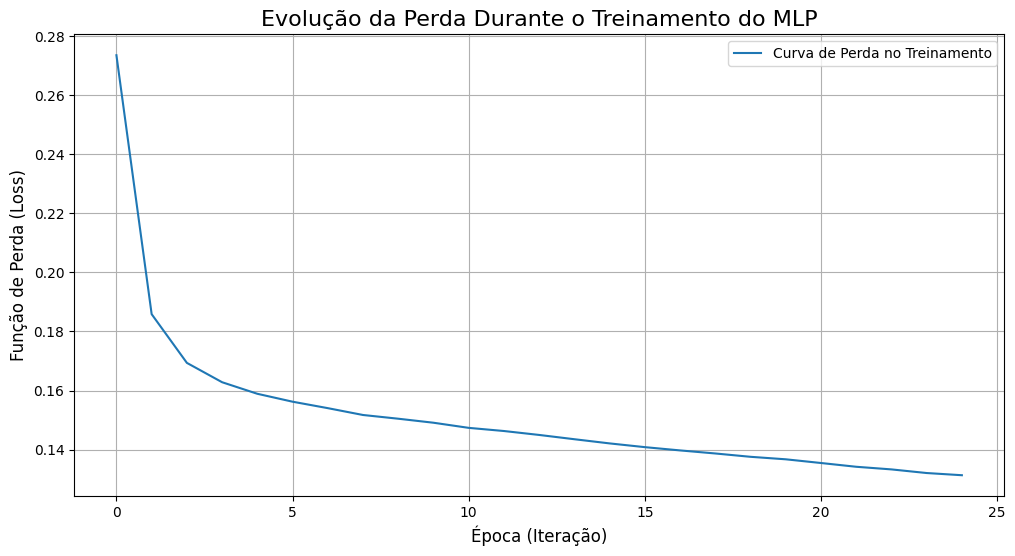

In [8]:
y_pred = mlp_model.predict(X_teste)
y_pred_proba = mlp_model.predict_proba(X_teste)

# --- Relatório de Classificação ---
print("--- Relatório de Classificação (MLPClassifier) ---")
print(classification_report(y_teste, y_pred, target_names=label_encoder.classes_.astype(str), zero_division=0))

# --- F1-Score Ponderado ---
f1 = f1_score(y_teste, y_pred, average='weighted')
print(f"\nF1-Score (Ponderado): {f1:.4f}")

# --- Matriz de Confusão (Normalizada/Recall) ---
cm_norm = confusion_matrix(y_teste, y_pred)
cm_norm = cm_norm.astype('float') / cm_norm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(14, 10))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='viridis',
            xticklabels=label_encoder.classes_.astype(str),
            yticklabels=label_encoder.classes_.astype(str))
plt.title('Matriz de Confusão Normalizada (Recall) - MLPClassifier', fontsize=16)
plt.ylabel('Rótulo Verdadeiro', fontsize=12)
plt.xlabel('Rótulo Previsto', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

# --- Curva de Perda do Treinamento ---
plt.figure(figsize=(12, 6))
plt.plot(mlp_model.loss_curve_, label='Curva de Perda no Treinamento')
plt.title('Evolução da Perda Durante o Treinamento do MLP', fontsize=16)
plt.xlabel('Época (Iteração)', fontsize=12)
plt.ylabel('Função de Perda (Loss)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


### 6. Salvando o Modelo MLPClassifier

 Embora não tenha se tornado o "especialista" em ataques web que esperávamos, o MLPClassifier provou ser um excelente modelo "generalista" com uma performance geral muito forte (F1 Ponderado de ~0.94).

 Sua abordagem de aprendizado, fundamentalmente diferente dos modelos de árvore, o torna um candidato ideal para adicionar diversidade e robustez ao nosso ensemble final. Ele será o quarto membro do nosso ensemble.

In [9]:
import os
import joblib

# --- Define o diretório de salvamento ---
try:
    project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
except:
    project_root = os.getcwd()

model_dir = os.path.join(project_root, 'models')

if not os.path.exists(model_dir):
    os.makedirs(model_dir)
    print(f"Diretório criado: {model_dir}")

# --- Salva o modelo treinado ---
model_path = os.path.join(model_dir, 'mlp_model.joblib')
joblib.dump(mlp_model, model_path)
print(f"Modelo MLPClassifier salvo em: {model_path}")

# --- Verificação Final ---
print("\n--- Verificando arquivos salvos no diretório 'models' ---")
try:
    print(sorted(os.listdir(model_dir)))
except Exception as e:
    print(f"Não foi possível listar os arquivos: {e}")

Modelo MLPClassifier salvo em: /home/henrique/PycharmProjects/ndr-tcc/models/mlp_model.joblib

--- Verificando arquivos salvos no diretório 'models' ---
['catboost_model.joblib', 'ensemble_model.joblib', 'features_realistas.joblib', 'isolation_forest_model.joblib', 'label_encoder.joblib', 'mlp_model.joblib', 'random_forest_model.joblib', 'top_15_features.joblib', 'xgboost_model.joblib']
